In [1]:
# Nama: Ridho Amanta Silaban
# NIM: 4222301091
# Kelas: C Pagi

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [3]:
df = pd.read_csv('WineQT.csv')

## EDA

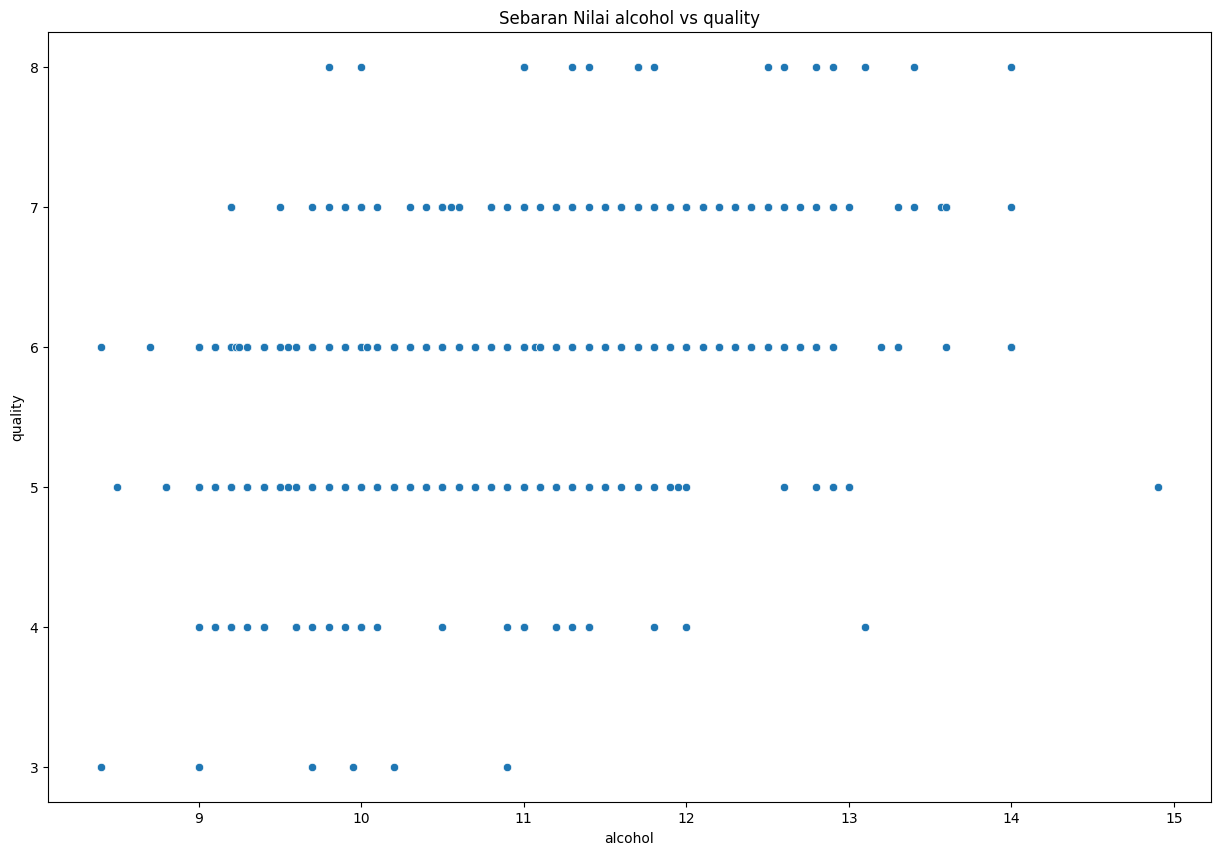

In [4]:
# Scatter plot: alcohol vs quality
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality')
plt.title('Sebaran Nilai alcohol vs quality')
plt.show()

In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


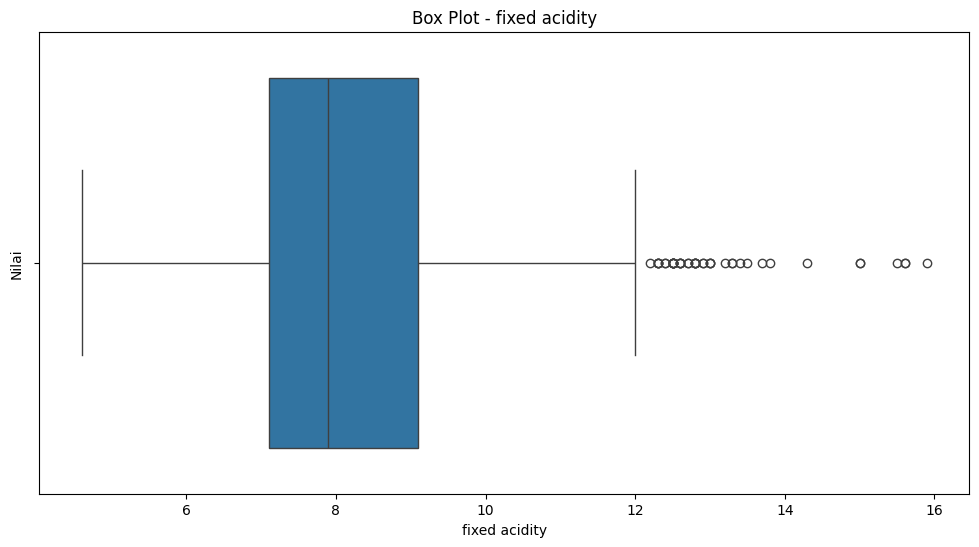

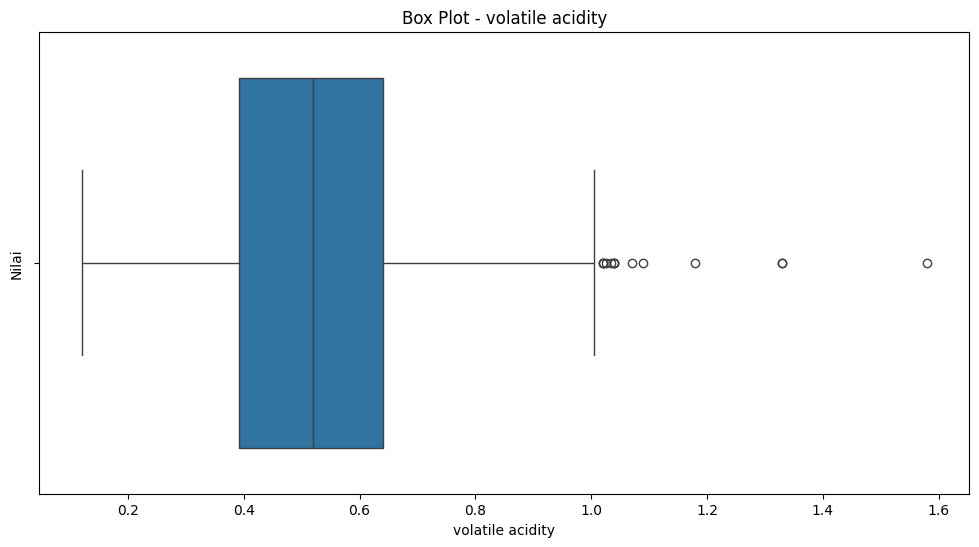

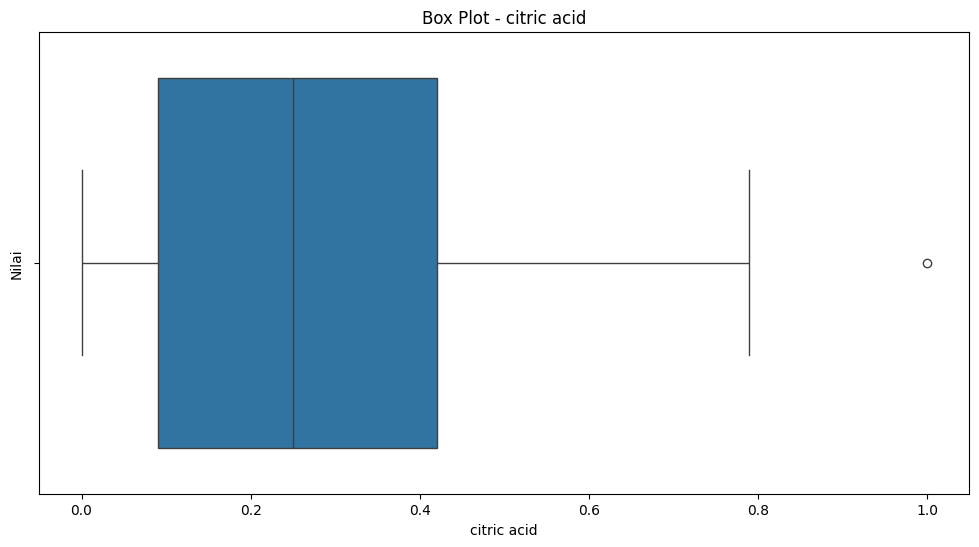

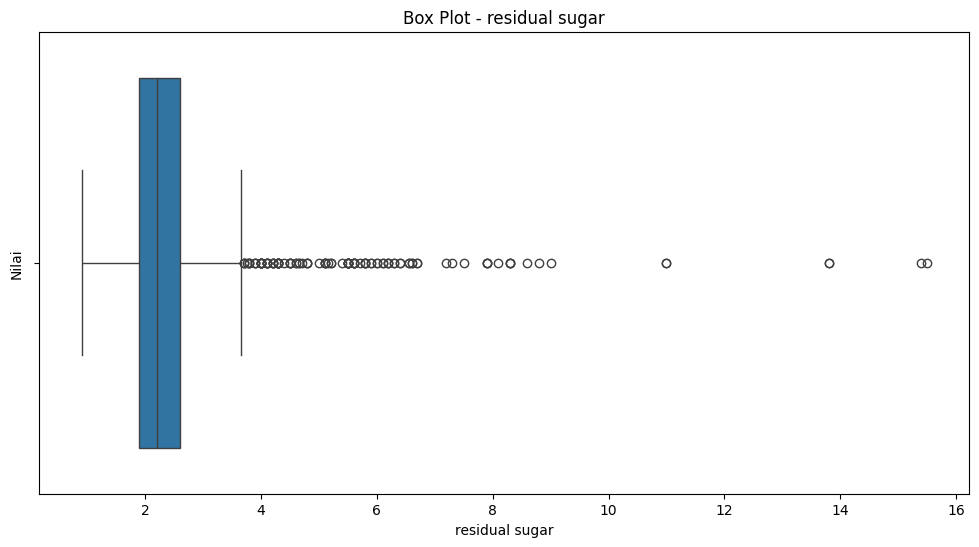

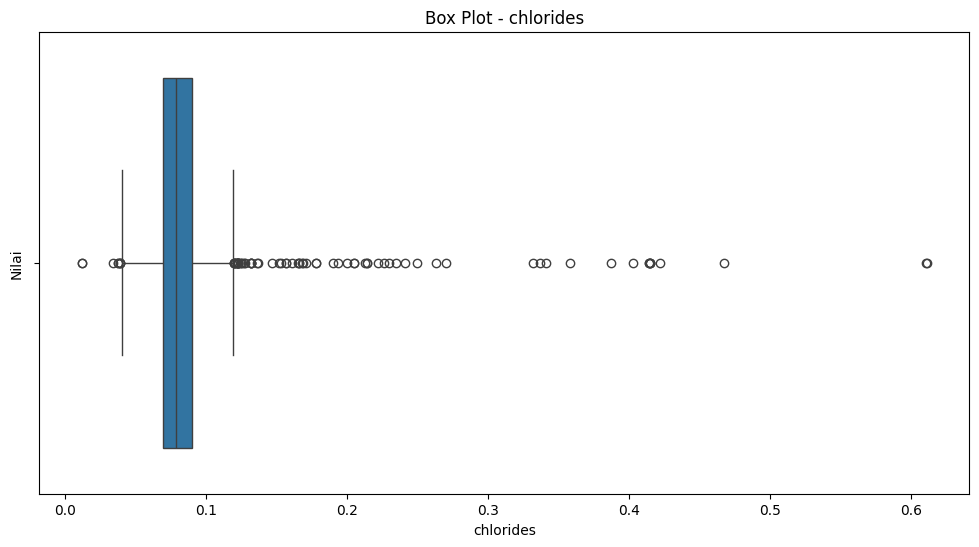

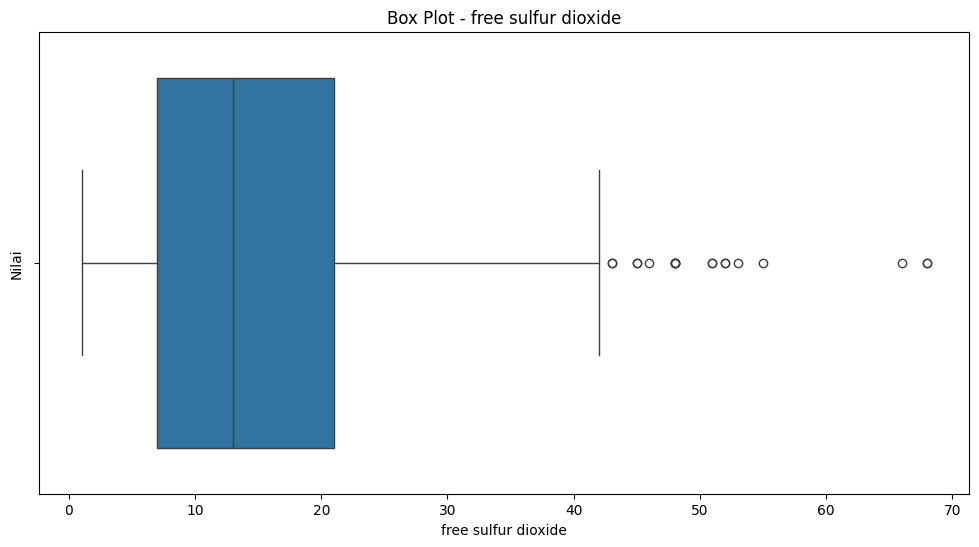

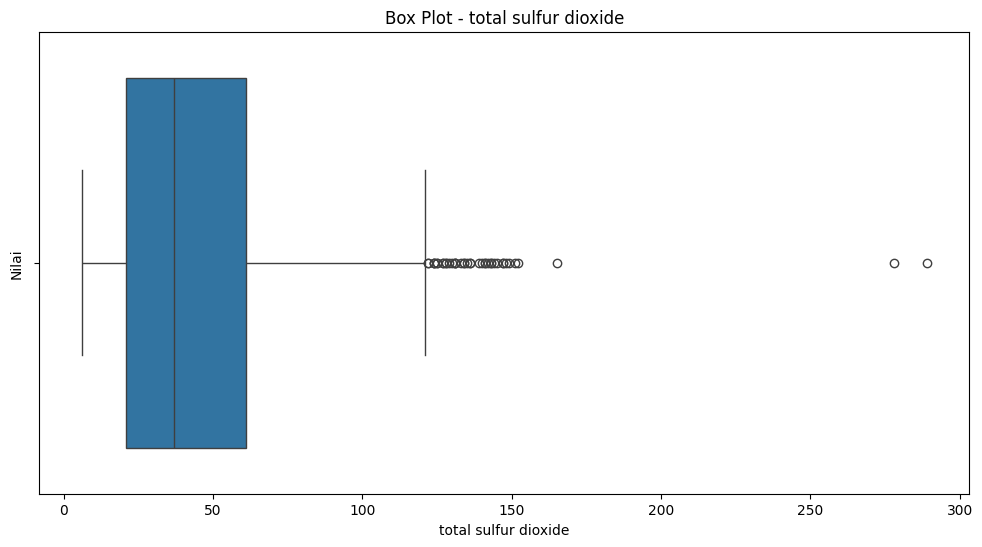

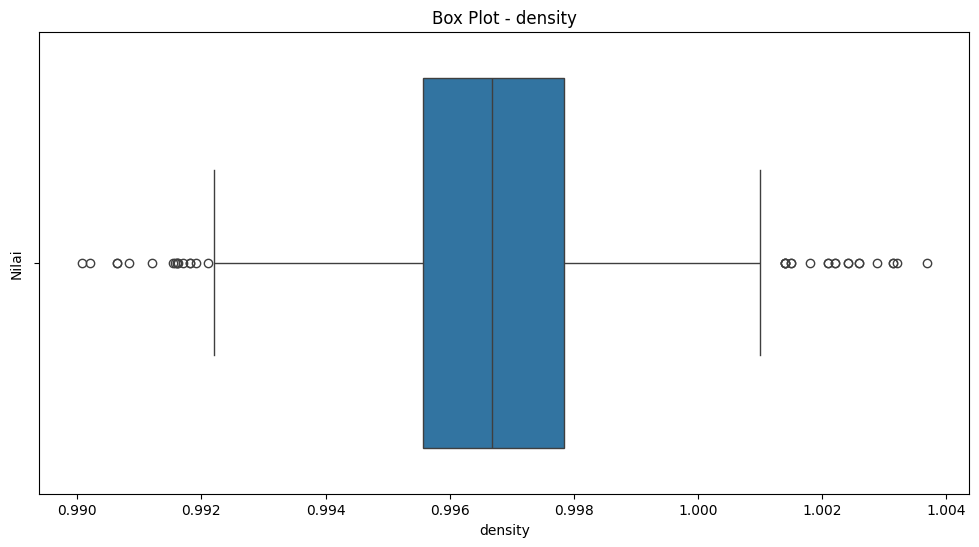

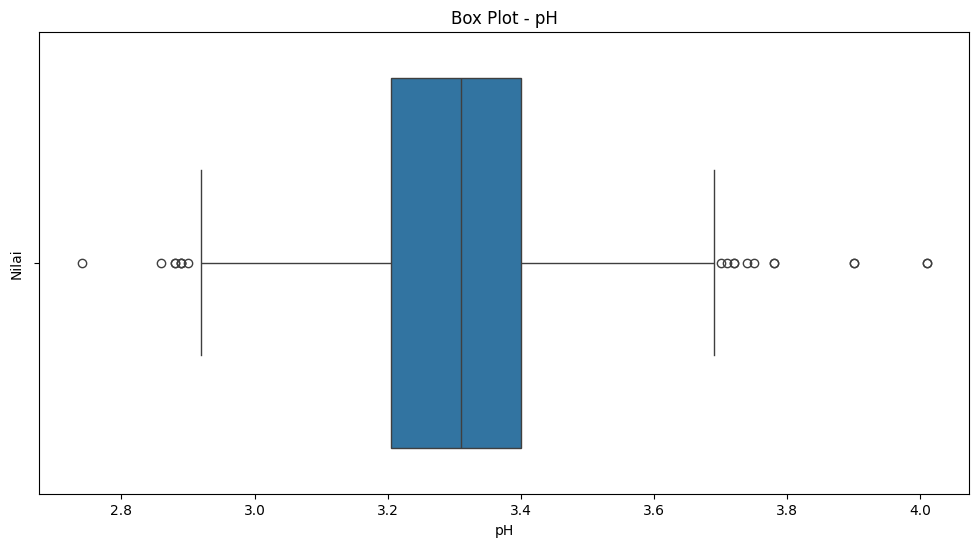

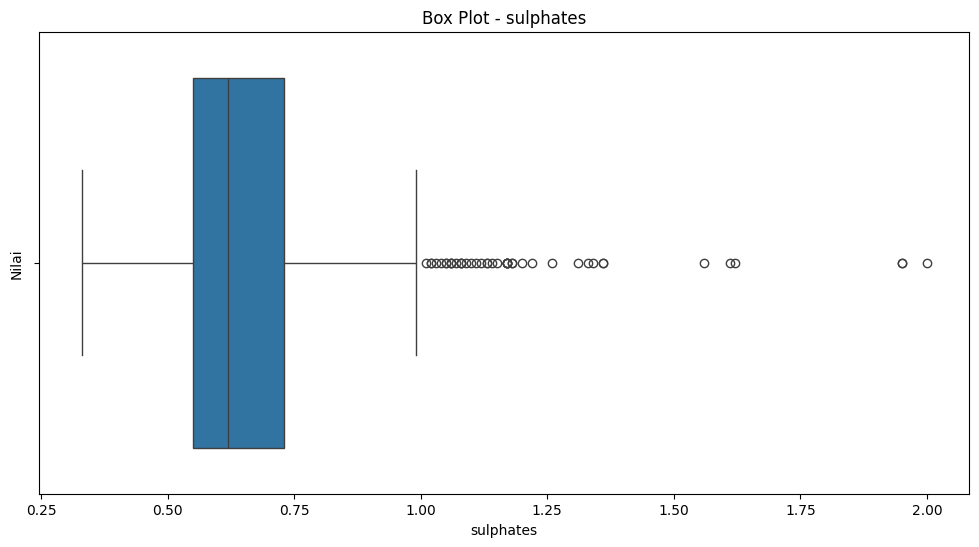

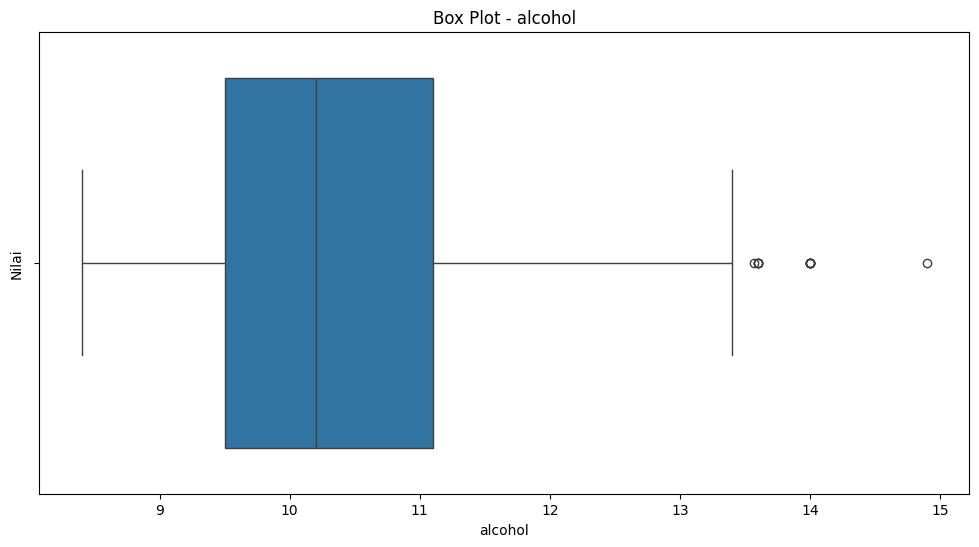

In [6]:
# Box plot
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                 'density', 'pH', 'sulphates', 'alcohol']

for col in fitur_columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

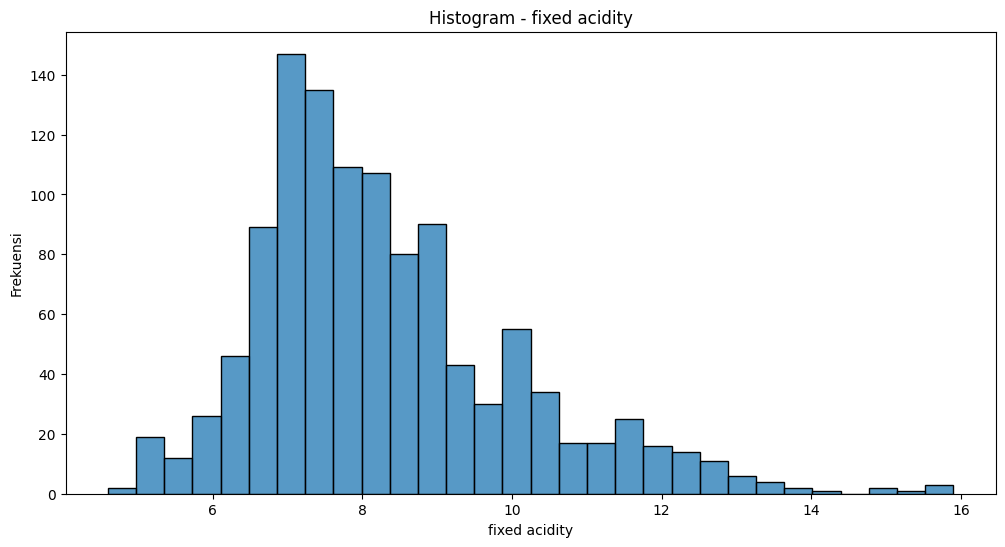

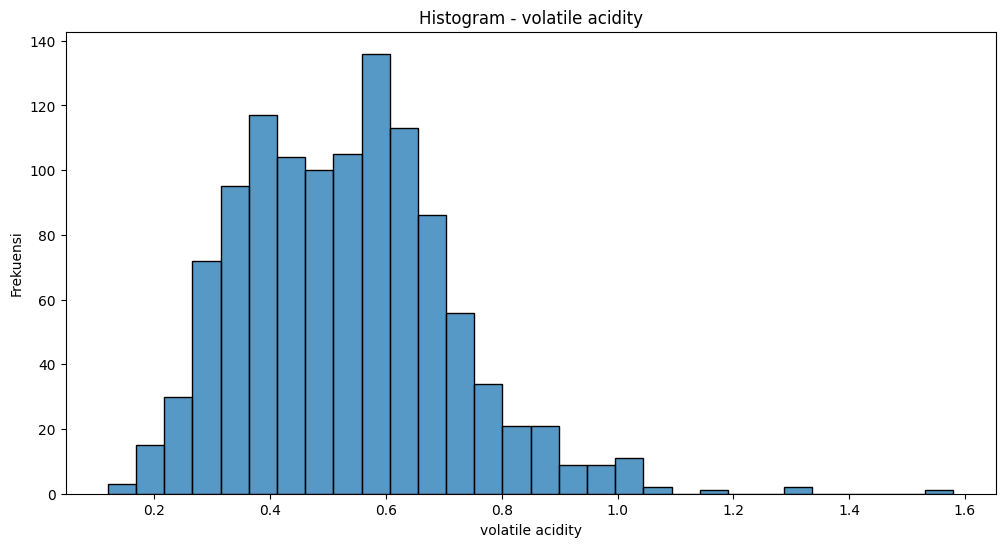

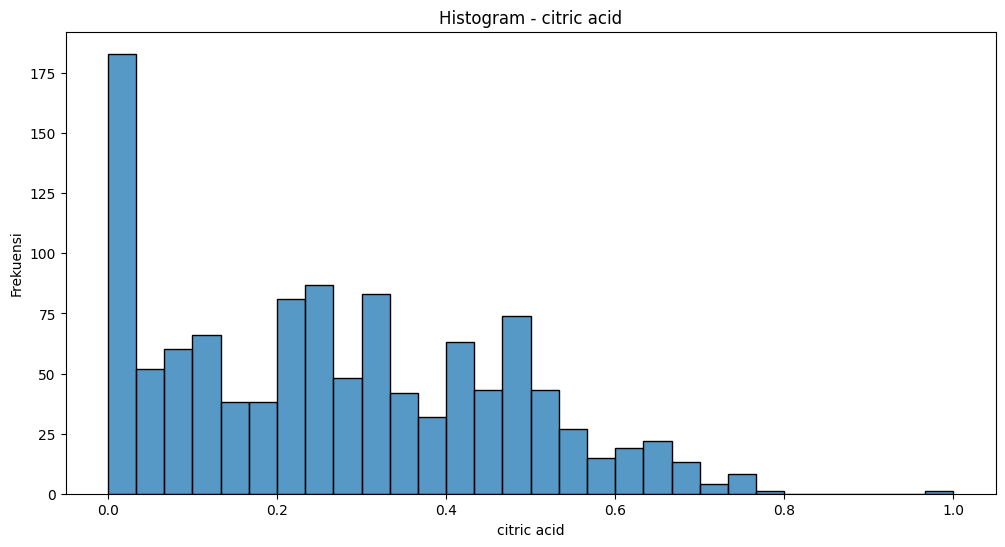

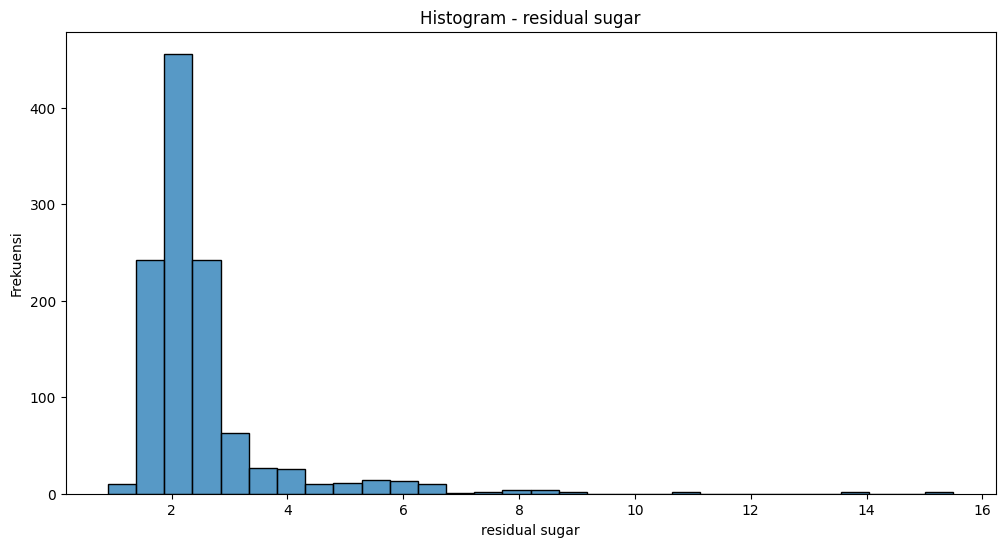

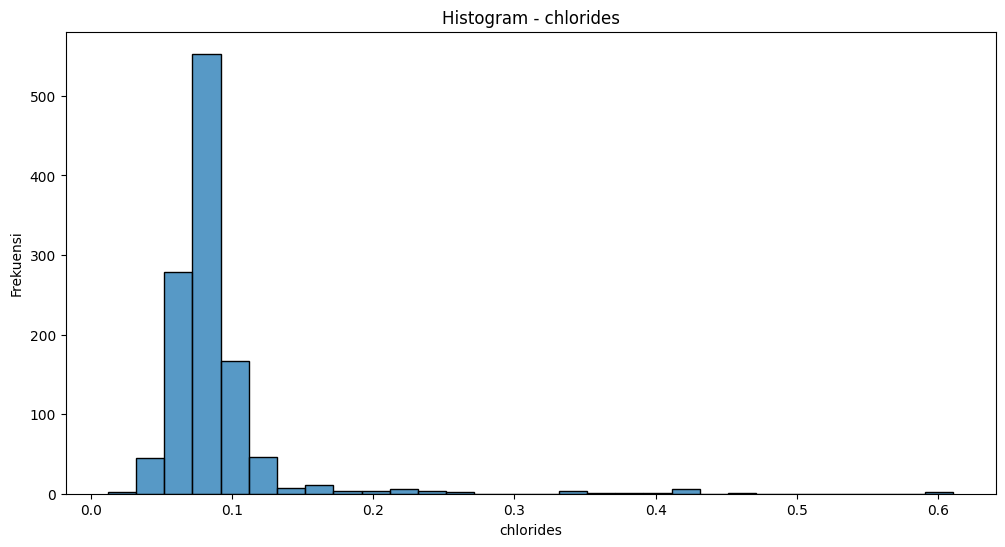

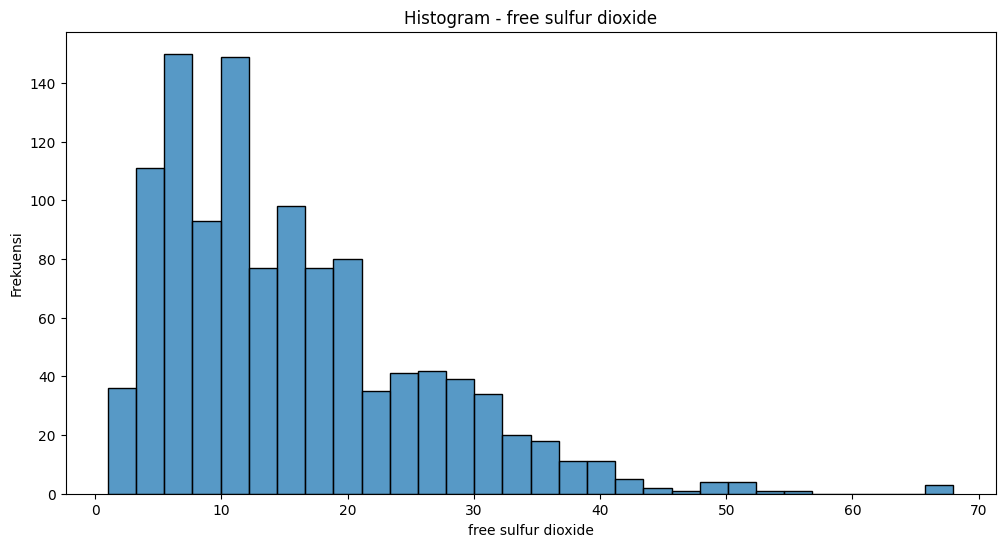

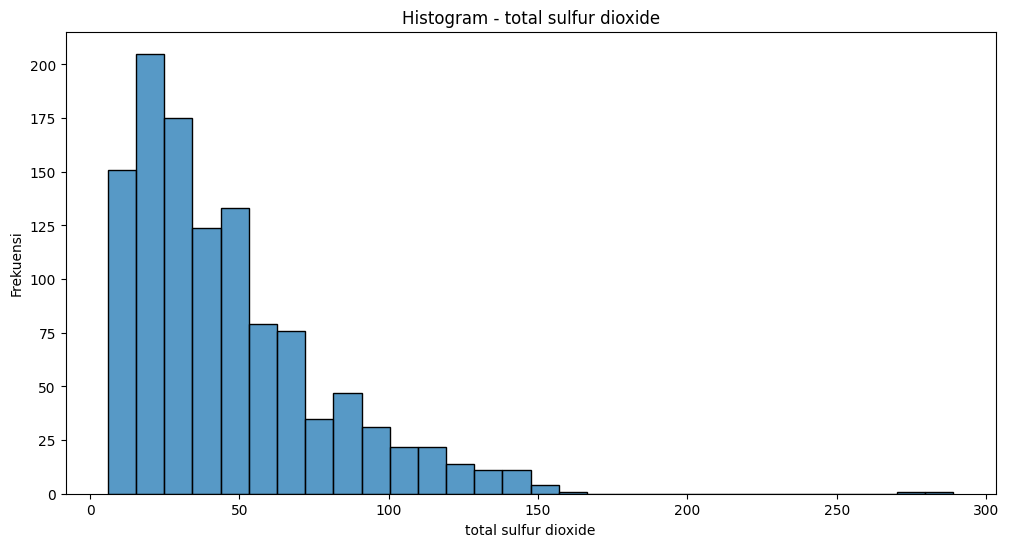

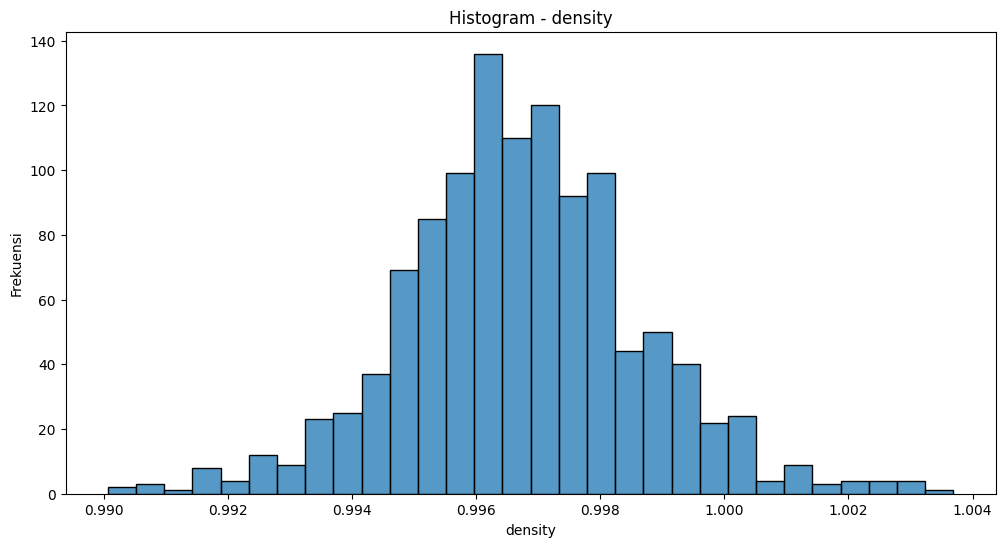

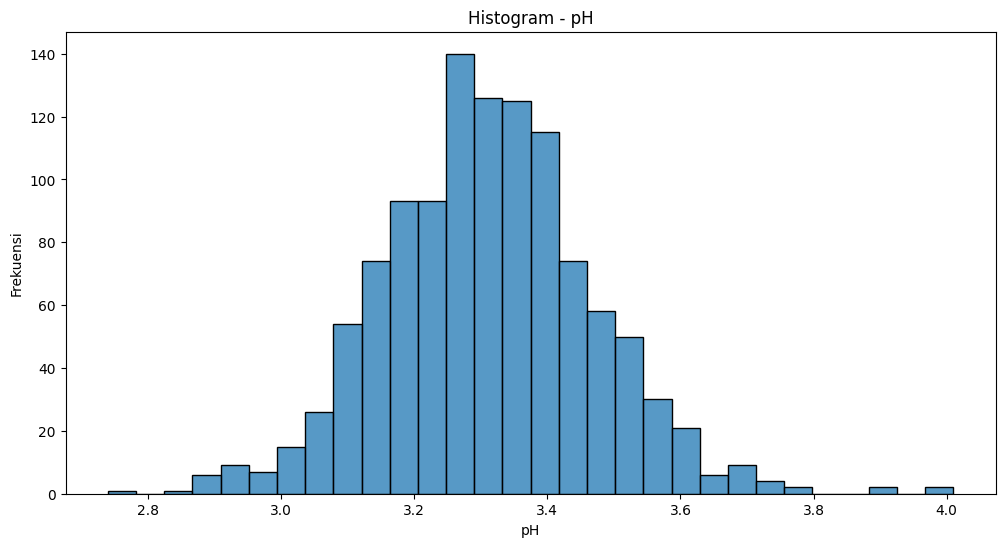

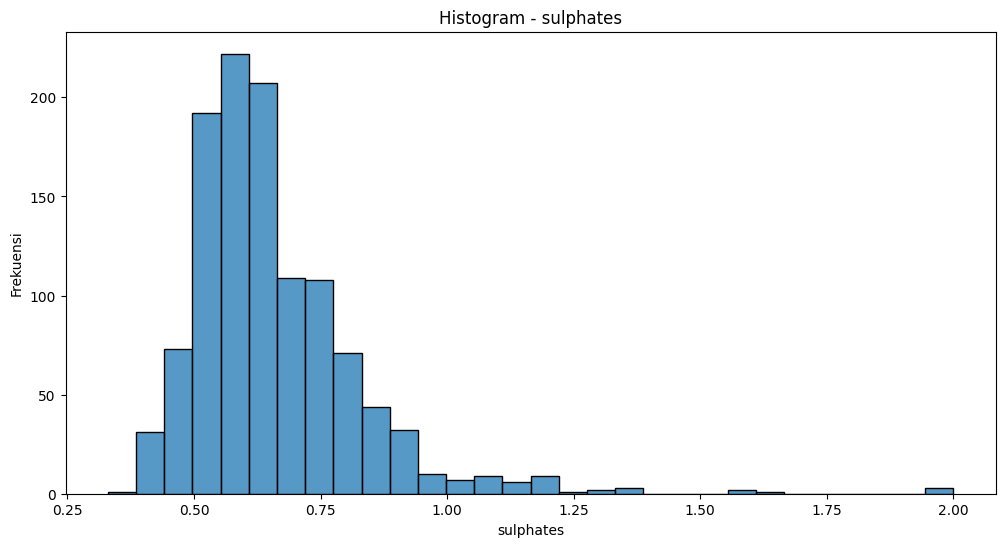

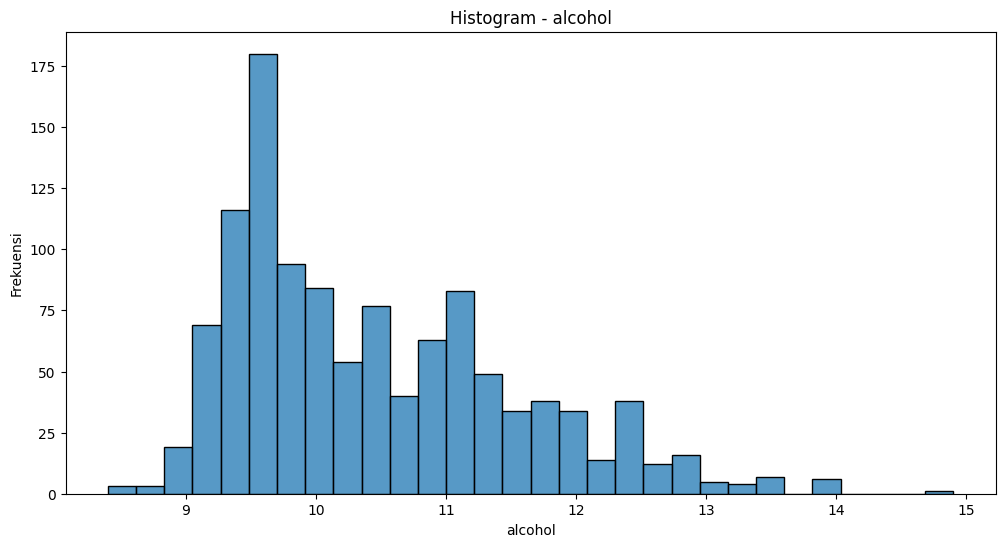

In [7]:
# Histogram
for col in fitur_columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)
3. Feature Scaling

In [8]:
# Drop Duplicates
print(f"Dataframe dimension before duplication drop {df.shape[0]}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [9]:
# Pisahkan fitur numerik dan label
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                 'density', 'pH', 'sulphates', 'alcohol']

X = df[fitur_columns].values
y = df['quality'].values  # label anotator (kualitas wine)

In [10]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data=X_std, columns=fitur_columns)
df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00


In [11]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, ...,  1.27069495,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, ..., -0.70892755,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.32577481,
        -0.04525363, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ...,  0.88754221,
        -0.45623467,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  1.33455374,
         0.60057372,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  1.65384769,
         0.30701583, -0.22382033]])

In [12]:
df_scalling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

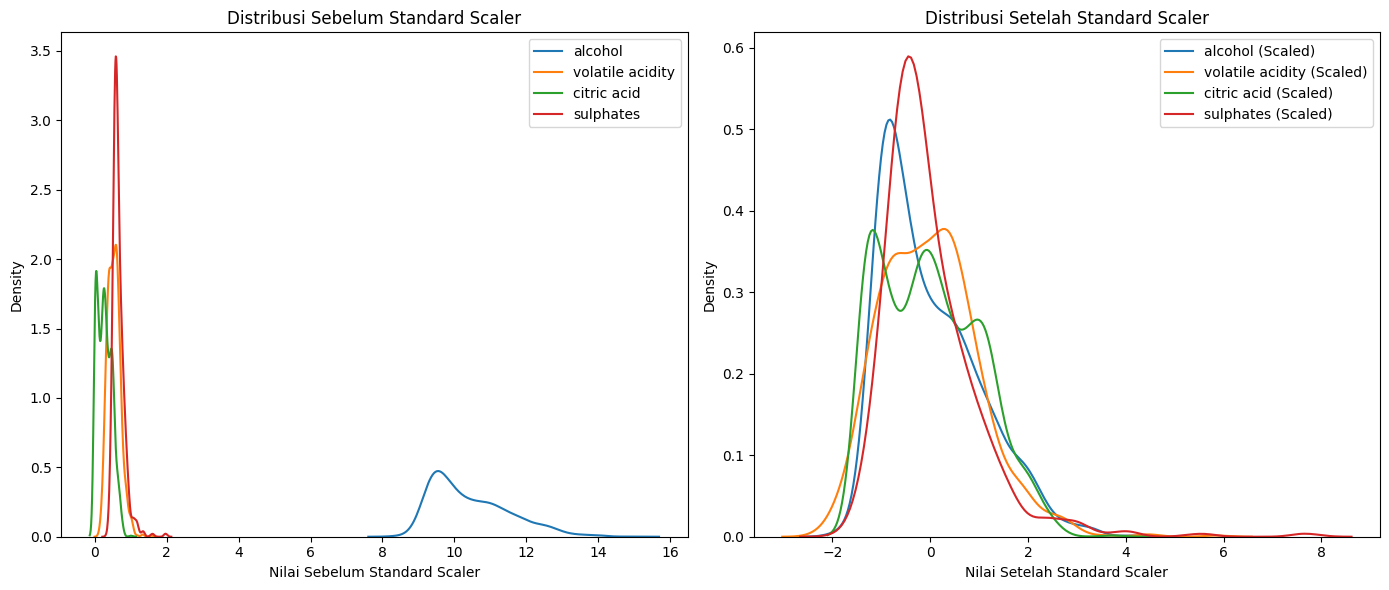

In [13]:
# Cek grafik sebelum dan setelah scalling
# Kita pilih 2 fitur representatif: alcohol dan volatile acidity
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6))

# Plot distribusi sebelum Standard Scaler
ax1.set_title('Distribusi Sebelum Standard Scaler')
for col in ['alcohol', 'volatile acidity', 'citric acid', 'sulphates']:
    sns.kdeplot(df[col], ax=ax1, label=col)
ax1.set_xlabel('Nilai Sebelum Standard Scaler')
ax1.legend()

# Plot distribusi setelah Standard Scaler
ax2.set_title('Distribusi Setelah Standard Scaler')
for col in ['alcohol', 'volatile acidity', 'citric acid', 'sulphates']:
    sns.kdeplot(df_scalling[col], ax=ax2, label=f'{col} (Scaled)')
ax2.set_xlabel('Nilai Setelah Standard Scaler')
ax2.legend()

plt.tight_layout()
plt.show()

Terlihat perubahan skala antara sebelum menggunakan standard scaler dan sesudah menggunakan.
Sebelum scaling, skala antar fitur sangat berbeda (contoh: free sulfur dioxide hingga ratusan, density mendekati 1).
Setelah scaling, semua fitur memiliki mean mendekati 0 dan standar deviasi 1, sehingga distribusi lebih simetris dan sebanding.

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Sebelum Standard Scaler, setiap fitur memiliki skala yang sangat berbeda-beda (misalnya  bisa ratusan, sedangkan  hanya sekitar 0.99).
2. Setelah Standard Scaler, semua fitur memiliki mean mendekati 0 dan standar deviasi = 1, sehingga tidak ada fitur yang mendominasi karena perbedaan skala.
3. Pola distribusi (shape) tetap sama, hanya skalanya yang berubah.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

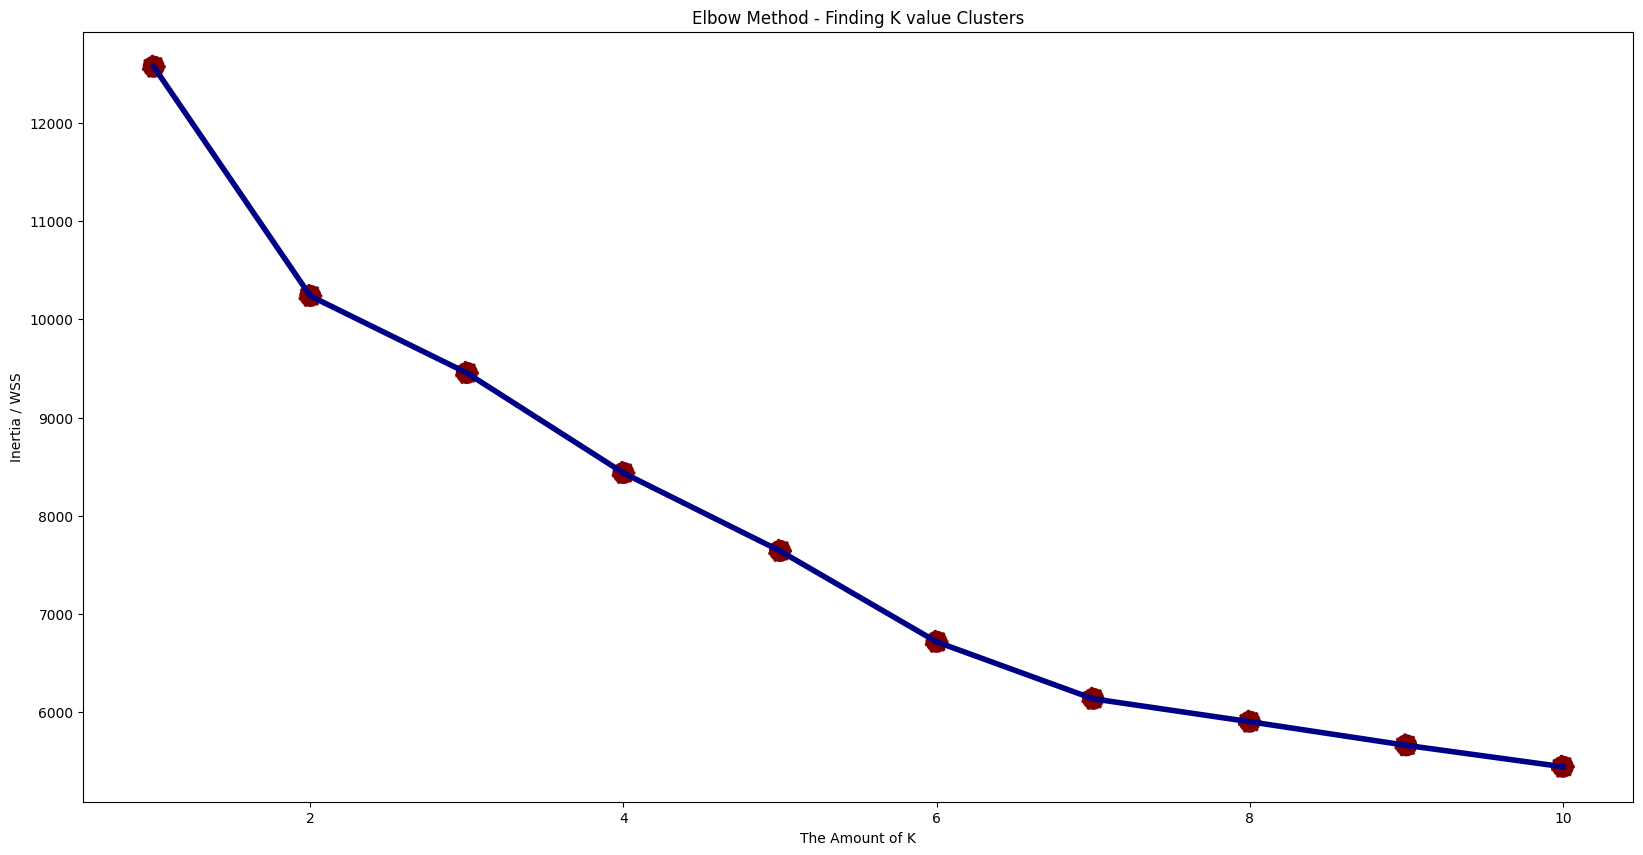

In [14]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))
sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth=4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000', linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Inertia / WSS')
plt.show()

In [24]:
# Dari hasil diatas elbow nya dipilih pada angka 3,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [26]:
# Taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [27]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1


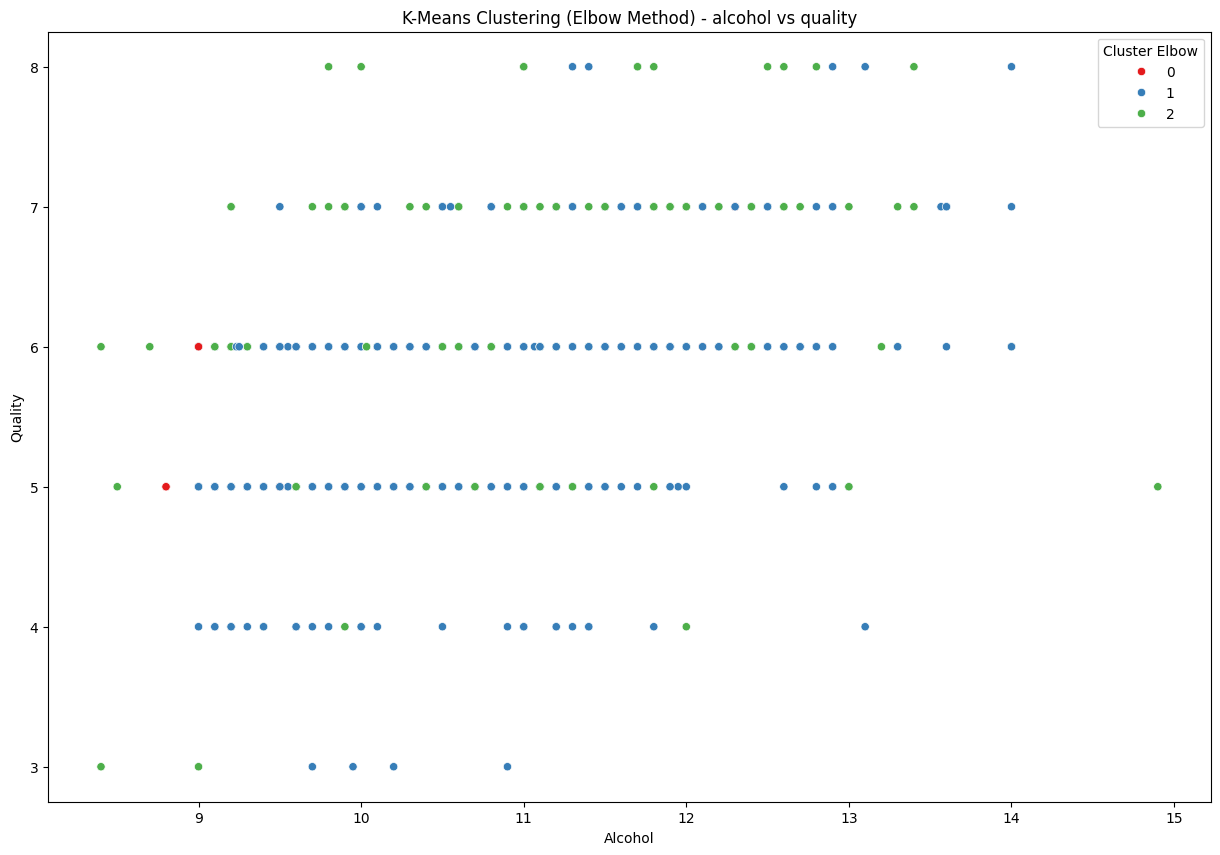

In [28]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_elbow', palette='Set1')
plt.title('K-Means Clustering (Elbow Method) - alcohol vs quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.legend(title='Cluster Elbow')
plt.show()

### Bandingkan hasil dengan label anotator

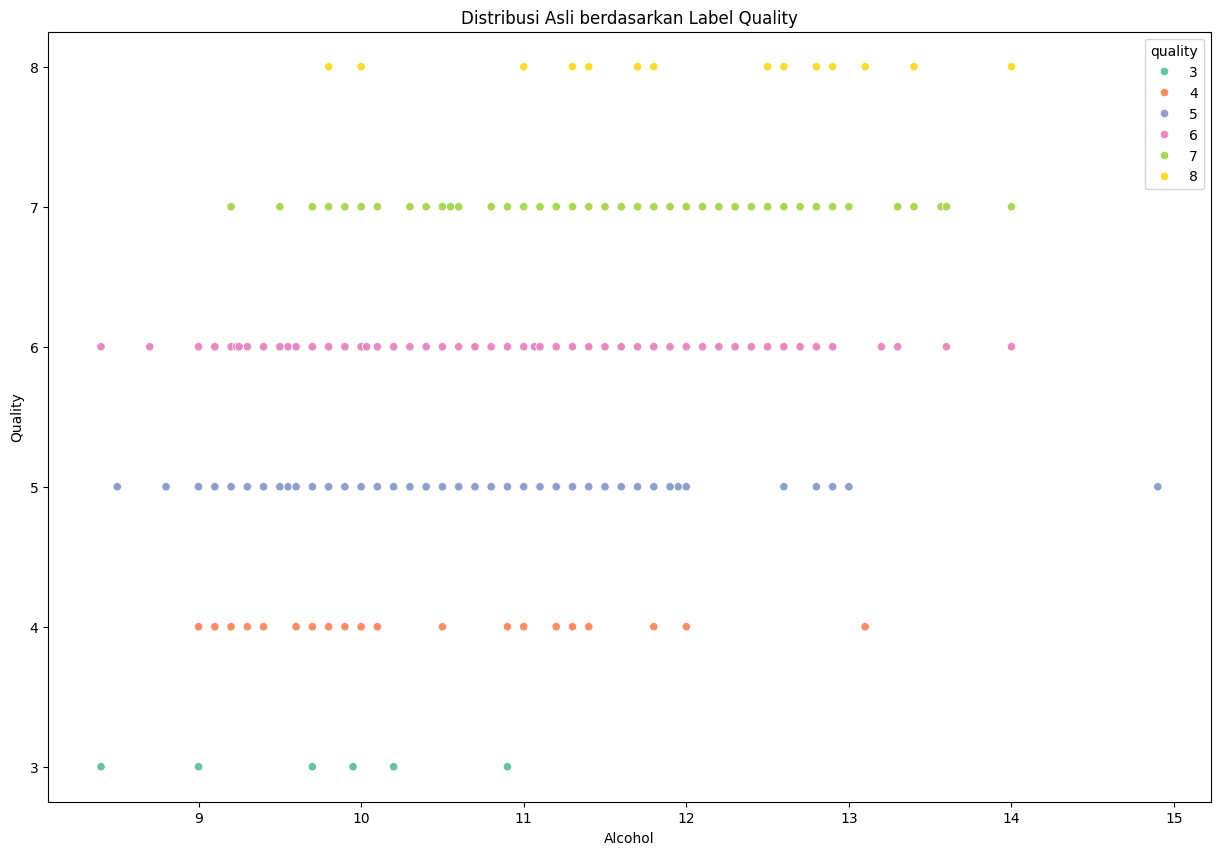

In [29]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='Set2')
plt.title('Distribusi Asli berdasarkan Label Quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.show()

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan pola sebaran kualitas wine. Dengan kondisi :
1. Cluster 0 -> Wine dengan kadar alcohol rendah dan kualitas menengah
2. Cluster 1 -> Wine dengan kadar alcohol tinggi dan kualitas tinggi
3. Cluster 2 -> Wine dengan karakteristik kimia berbeda (keasaman tinggi, kualitas rendah)

### 2. Via Score Plot

In [30]:
!pip install yellowbrick

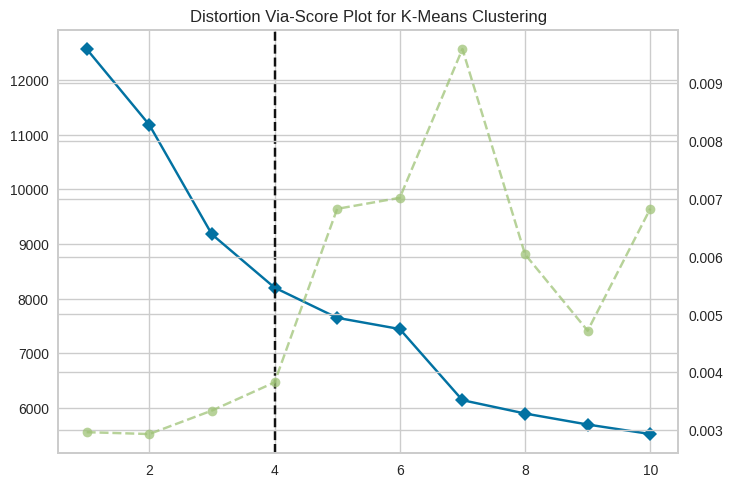

In [84]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings=True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [72]:
# Dari hasil diatas K-nya dipilih pada angka yang direkomendasikan visualizer,
# karena titik distorsinya bertemu pada nilai tersebut di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=4, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=5, random_state=0)

In [73]:
# Taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [74]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1,3
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1,4
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,4
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1,3
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1,3


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

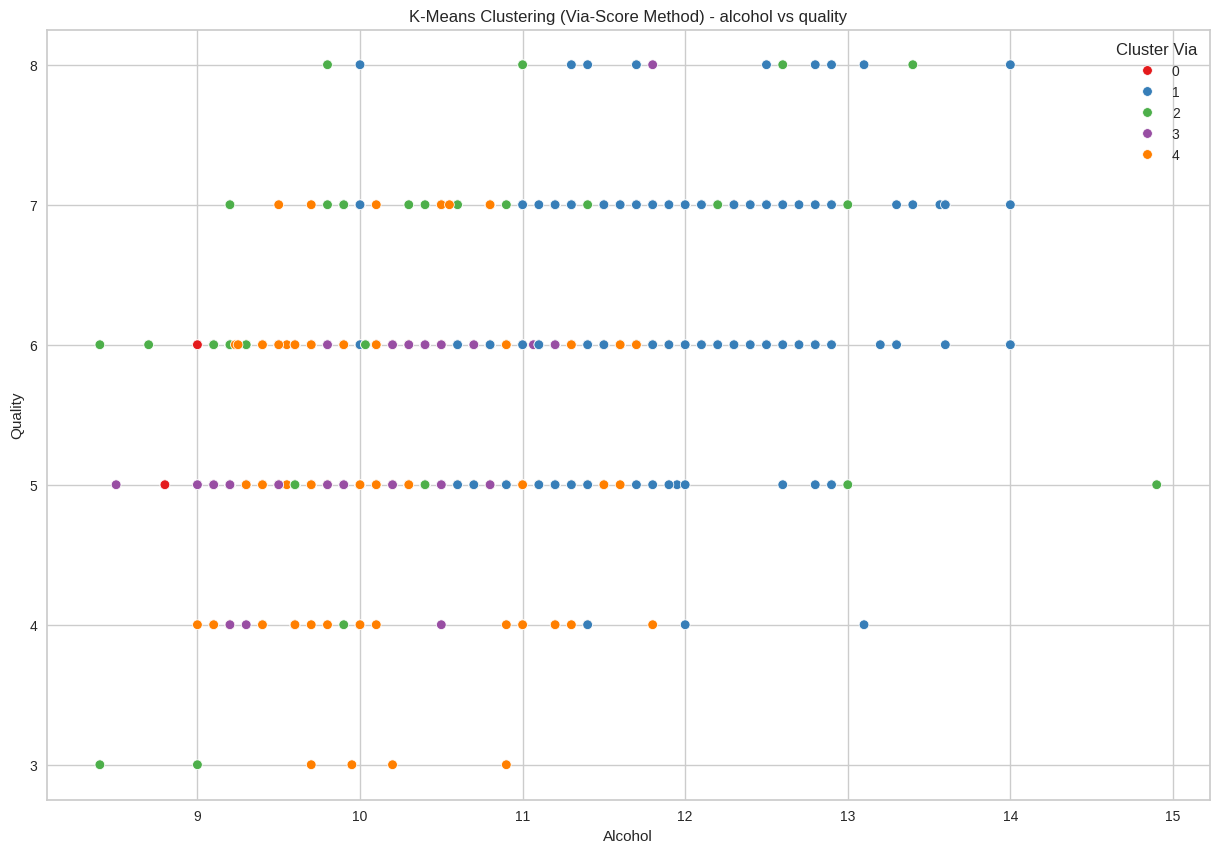

In [75]:
# Lakukan evaluasi setelah dilakukan K-Means
# Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_via', palette='Set1', ax=ax)
plt.title('K-Means Clustering (Via-Score Method) - alcohol vs quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.legend(title='Cluster Via')
plt.show()

### Bandingkan dengan label anotator

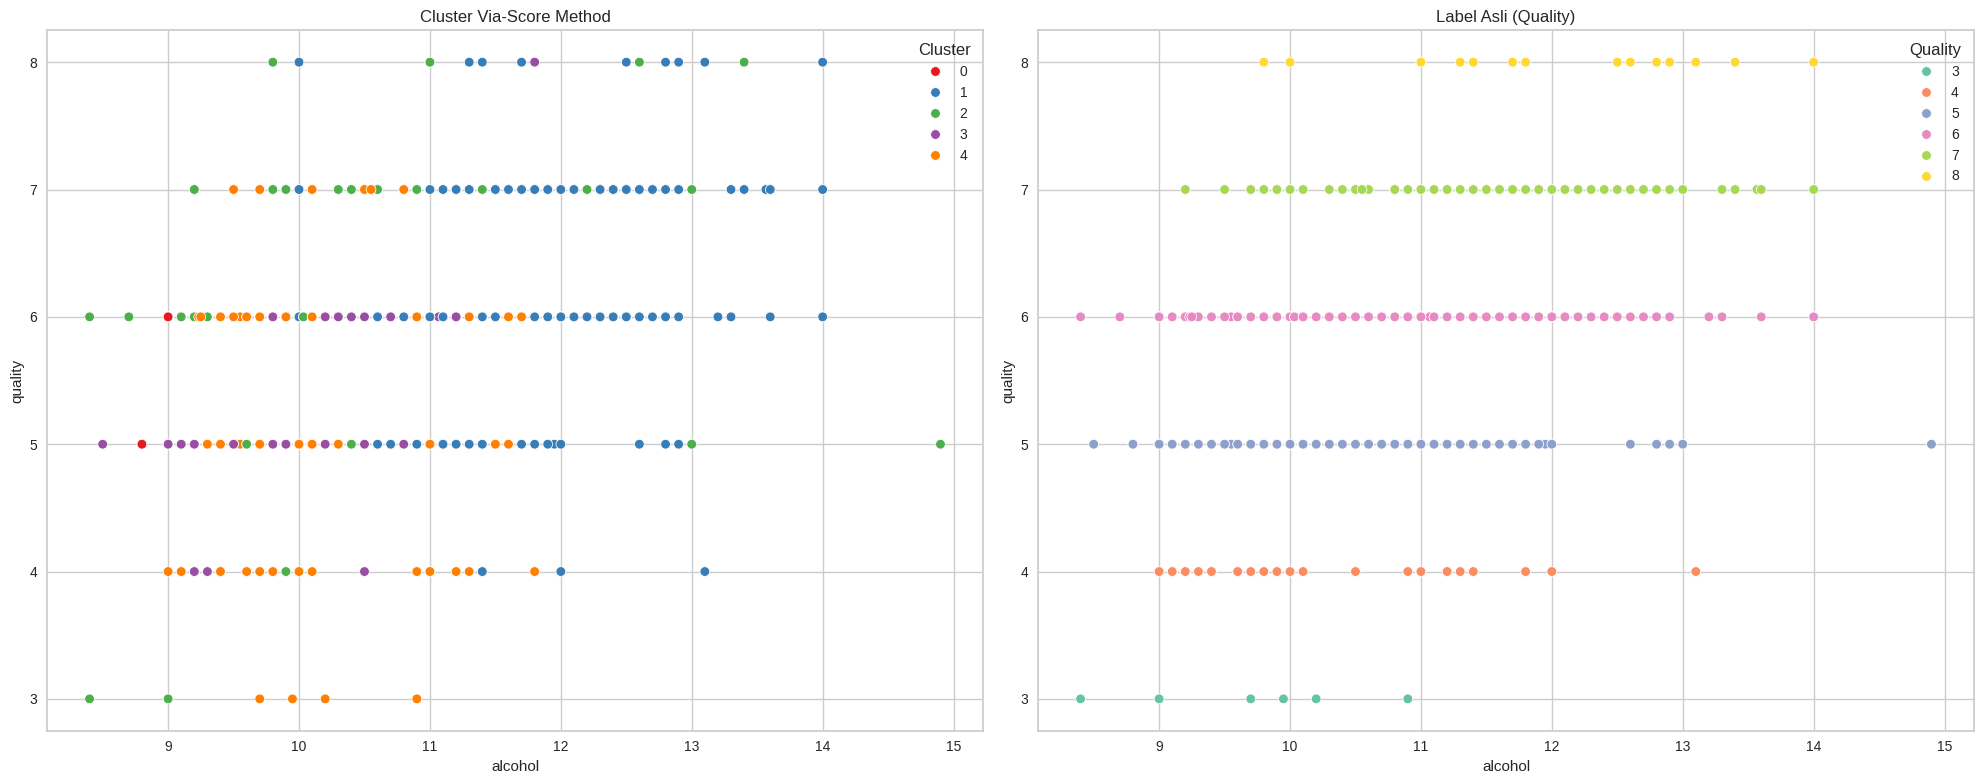

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Cluster Via
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_via', palette='Set1', ax=axes[0])
axes[0].set_title('Cluster Via-Score Method')
axes[0].legend(title='Cluster')

# Label Asli
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='Set2', ax=axes[1])
axes[1].set_title('Label Asli (Quality)')
axes[1].legend(title='Quality')

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Meskipun jumlah cluster pada via-score method 4 cluster, persebaran tiap cluster berbeda dengan label quality asli yang memiliki 6 kategori (3-8).
2. Label "quality" asli memiliki rentang nilai 3-8 yang granular, sementara K-Means via-score mengelompokkan wine menjadi 3 kelompok besar berdasarkan kemiripan profil kimia.
3. Cluster dengan kadar  tinggi cenderung berkorelasi dengan kualitas wine yang lebih tinggi (quality 7-8), hal ini konsisten antara cluster_via dan label asli.
4. Perbedaan utama terjadi pada wine kualitas menengah (quality 5-6) yang tersebar ke beberapa cluster berbeda, karena profil kimianya yang beragam.

Perbedaan diatas dikarenakan K-Means melakukan clustering berdasarkan semua 11 fitur kimia wine secara bersamaan, sedangkan label  adalah penilaian subjektif ahli wine. Oleh karena itu, terdapat tumpang tindih antara cluster dan label asli pada kualitas menengah.

### Thank you :)